<a href="https://colab.research.google.com/github/binittababu20-cmd/data-science/blob/main/pg8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment: Wine Quality Analysis and k-NN Classification

dfset: Wine_Quality.csv

Write a Python program to:

a) Perform Exploratory df Analysis (EDA):

• Display the first five records.

• Check for missing values.

• Display descriptive statistics.

• Display the distribution of wine quality.

b) Visualize the df using:

• Scatter plot of alcohol vs. pH.

• Histogram of alcohol.

• Box plot of alcohol grouped by quality.

c) Implement k-NN Classification:

• Remove missing values and prepare features and target.

• Split the df into 80% training and 20% testing sets.

• Standardize the features using StandardScaler.

• Apply k-NN with different values of k and display the accuracy.

• Allow the user to enter k values and display the corresponding accuracy.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df=pd.read_csv('/content/WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [ ]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         


========== WINE QUALITY DISTRIBUTION ==========
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


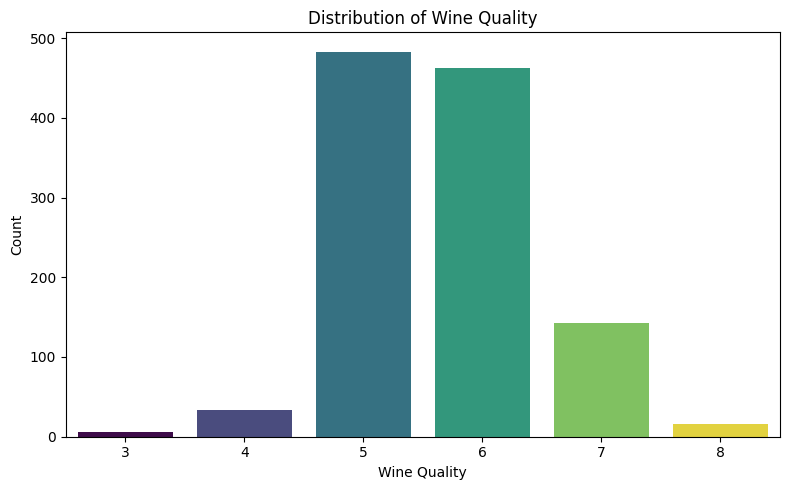

In [ ]:
print("\n========== WINE QUALITY DISTRIBUTION ==========")
print(df["quality"].value_counts().sort_index())

# Plot distribution of wine quality
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality", hue="quality", palette="viridis", legend=False)
plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

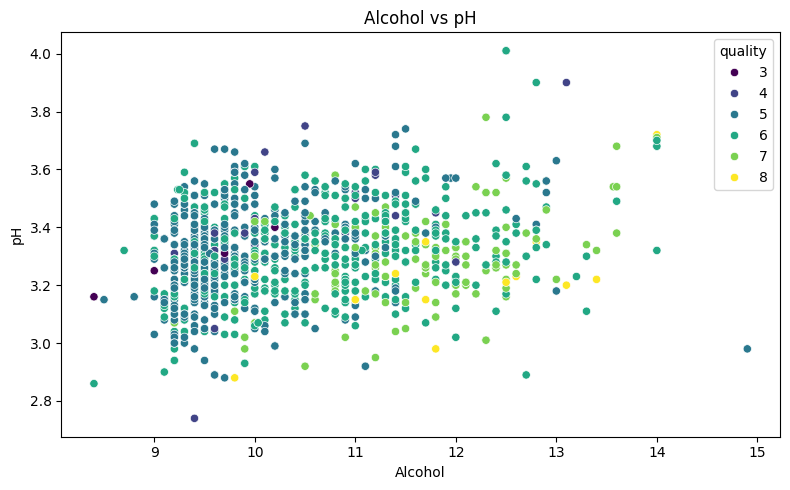

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="alcohol", y="pH", hue="quality", palette="viridis")
plt.title("Alcohol vs pH")
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.tight_layout()
plt.show()

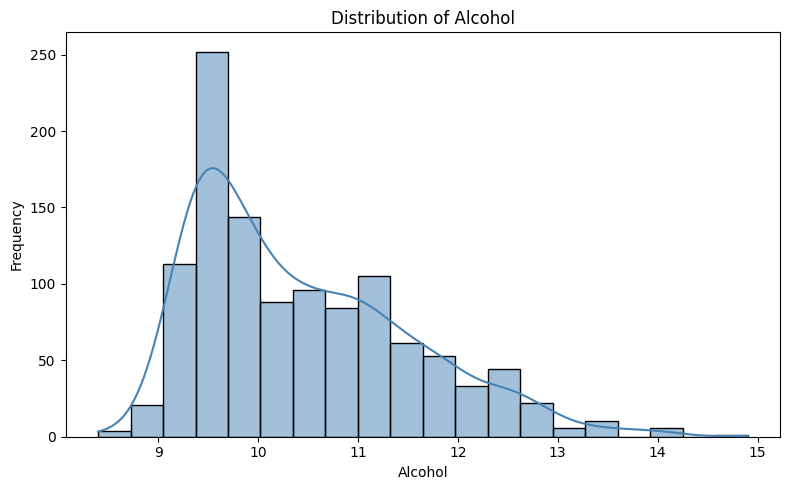

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["alcohol"], bins=20, kde=True, color="steelblue")
plt.title("Distribution of Alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

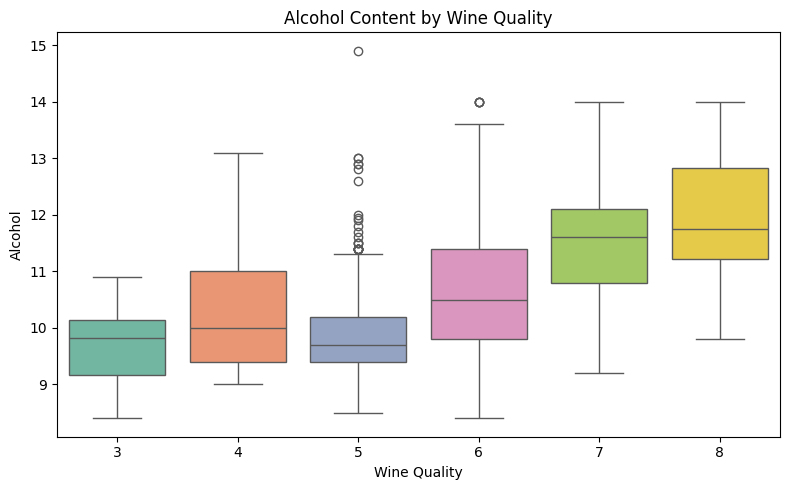

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="quality", y="alcohol", hue="quality",
            palette="Set2", legend=False)
plt.title("Alcohol Content by Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.dropna().copy()

In [ ]:
X = df_clean.drop("quality", axis=1)
y = df_clean["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 16)

accuracies = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    accuracies[k] = accuracy

    print(f"k = {k:2d} --> Accuracy = {accuracy:.4f}")


# Find the best k
best_k = max(accuracies, key=accuracies.get)

print("\nBest k value:", best_k)
print("Best accuracy:", f"{accuracies[best_k]:.4f}")

k =  1 --> Accuracy = 0.6114
k =  2 --> Accuracy = 0.5721
k =  3 --> Accuracy = 0.5677
k =  4 --> Accuracy = 0.5677
k =  5 --> Accuracy = 0.5764
k =  6 --> Accuracy = 0.5895
k =  7 --> Accuracy = 0.6332
k =  8 --> Accuracy = 0.6114
k =  9 --> Accuracy = 0.6070
k = 10 --> Accuracy = 0.6026
k = 11 --> Accuracy = 0.6070
k = 12 --> Accuracy = 0.6288
k = 13 --> Accuracy = 0.6114
k = 14 --> Accuracy = 0.6201
k = 15 --> Accuracy = 0.6201

Best k value: 7
Best accuracy: 0.6332


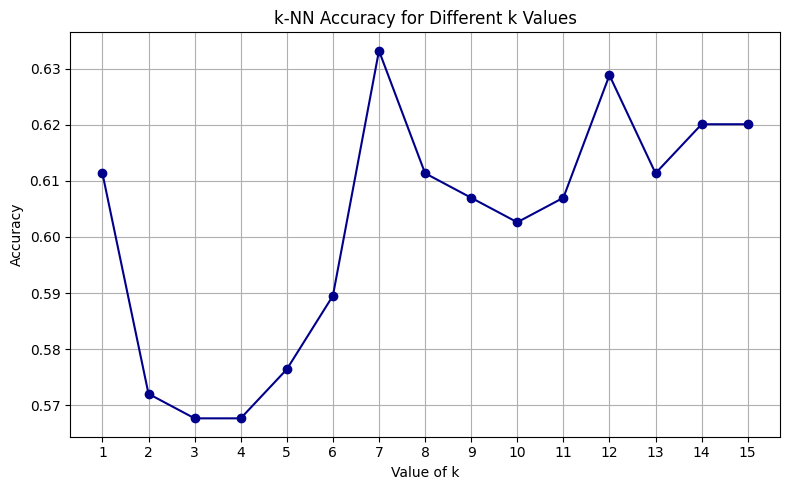

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    list(accuracies.keys()),
    list(accuracies.values()),
    marker="o",
    color="darkblue"
)

plt.title("k-NN Accuracy for Different k Values")
plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print("\n========== ENTER YOUR OWN k VALUES ==========")

while True:
    user_input = input(
        "\nEnter k values separated by spaces "
        "(or type 'q' to quit): "
    )

    if user_input.lower() == "q":
        print("Program ended.")
        break

    try:
        user_k_values = [int(k) for k in user_input.split()]

        for k in user_k_values:
            if k <= 0:
                print(f"k = {k} is invalid. k must be positive.")
                continue

            if k > len(X_train):
                print(
                    f"k = {k} is invalid. "
                    f"k cannot exceed the number of training samples "
                    f"({len(X_train)})."
                )
                continue

            # Create and train k-NN model
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_scaled, y_train)

            # Predict test df
            y_pred = knn.predict(X_test_scaled)

            # Calculate accuracy
            accuracy = accuracy_score(y_test, y_pred)

            print(f"k = {k} --> Accuracy = {accuracy:.4f}")

    except ValueError:
        print("Please enter valid integer k values.")


========== ENTER YOUR OWN k VALUES ==========

Enter k values separated by spaces (or type 'q' to quit): 1 2 3 4
k = 1 --> Accuracy = 0.6114
k = 2 --> Accuracy = 0.5721
k = 3 --> Accuracy = 0.5677
k = 4 --> Accuracy = 0.5677

Enter k values separated by spaces (or type 'q' to quit): 7 6 8 9
k = 7 --> Accuracy = 0.6332
k = 6 --> Accuracy = 0.5895
k = 8 --> Accuracy = 0.6114
k = 9 --> Accuracy = 0.6070

Enter k values separated by spaces (or type 'q' to quit): q
Program ended.
